# 01 — EDA: TotalCapture IMU → 3D Skeleton

Разведочный анализ датасета TotalCapture (subject S1).

**Задача**: регрессия 3D-позиций суставов верхней части тела (14 суставов) по показаниям 13 IMU-сенсоров (ориентация в кватернионах + акселерометр + гироскоп + магнитометр).

**Метрика**: **MPJPE** (Mean Per-Joint Position Error, в единицах BVH ≈ см) — стандартная для задач 3D-позы; усредняет евклидово расстояние между предсказанными и истинными позициями всех суставов. RMSE/MAE как вспомогательные.

Почему MPJPE: метрика напрямую интерпретируется в физических единицах (расстояние в пространстве); устойчива к выбору системы координат (сравниваются точки, а не углы).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import preprocessing as pp
from src import modeling

sns.set_theme(style='whitegrid')
np.random.seed(42)

PROCESSED = '../data/processed'
FIG_DIR = '../report/images'
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Размер датасета

In [2]:
splits = {s: dict(np.load(os.path.join(PROCESSED, f'{s}.npz'), allow_pickle=True)) for s in ['train', 'val', 'test']}
sizes = pd.DataFrame({
    'split': list(splits.keys()),
    'frames': [d['X'].shape[0] for d in splits.values()],
    'features': [d['X'].shape[1] for d in splits.values()],
    'targets': [d['Y'].shape[1] for d in splits.values()],
    'takes': [list(d['actions']) for d in splits.values()],
})
sizes

,split,frames,features,targets,takes
0,train,31119,305,42,"[acting1, acting2, freestyle1, freestyle2, rom..."
1,val,6166,305,42,"[acting3, walking3]"
2,test,7982,305,42,"[freestyle3, rom3]"


**Объём.** ~31k кадров train / 6k val / 8k test (60 Гц, 12 записей по ~2-7 минут на subject S1).

**Сплит — по записям, не по кадрам.** Соседние кадры одной записи почти идентичны (∆=1/60 с), поэтому случайный сплит по кадрам дал бы train/test leakage и завышенный скор. Разделение по takes гарантирует, что test-записи не пересекаются с train.

**Покрытие категорий.** Все 4 типа активности (acting, freestyle, rom, walking) представлены и в train, и в hold-out (val ∪ test). Это контролирует обобщение по характеру движений.

## 2. Длительности записей

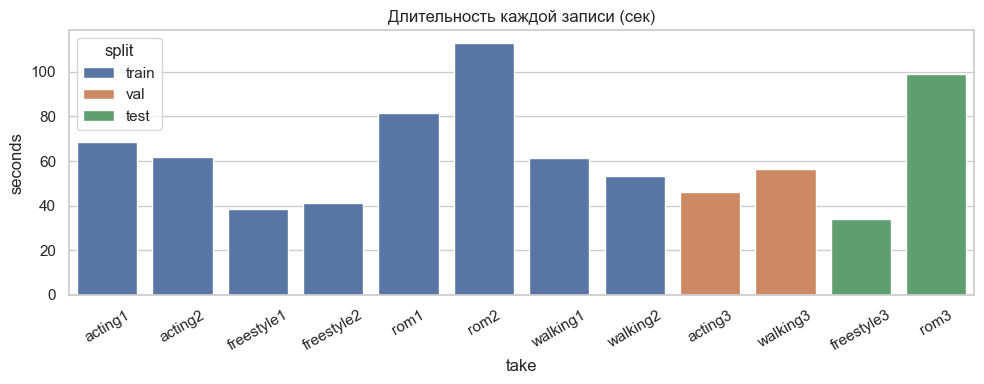

,split,take,frames,seconds
0,train,acting1,4114,68.566667
1,train,acting2,3703,61.716667
2,train,freestyle1,2311,38.516667
3,train,freestyle2,2464,41.066667
4,train,rom1,4891,81.516667
5,train,rom2,6776,112.933333
6,train,walking1,3671,61.183333
7,train,walking2,3189,53.150000
8,val,acting3,2769,46.150000
9,val,walking3,3397,56.616667


In [3]:
rows = []
for split, d in splits.items():
    take_id = d['take_id']
    for tid in np.unique(take_id):
        n = (take_id == tid).sum()
        rows.append({'split': split, 'take': str(d['actions'][tid]), 'frames': int(n), 'seconds': n / 60.0})
takes_df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(takes_df, x='take', y='seconds', hue='split', ax=ax)
ax.set_title('Длительность каждой записи (сек)')
plt.xticks(rotation=30)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/take_durations.png', dpi=120); plt.show()
takes_df

## 3. Распределения IMU-сигналов

Используем `raw_imu` (каждый сенсор: 4 quat + 3 accel + 3 gyro + 3 mag = 13 столбцов; всего 13×13 = 169 колонок).

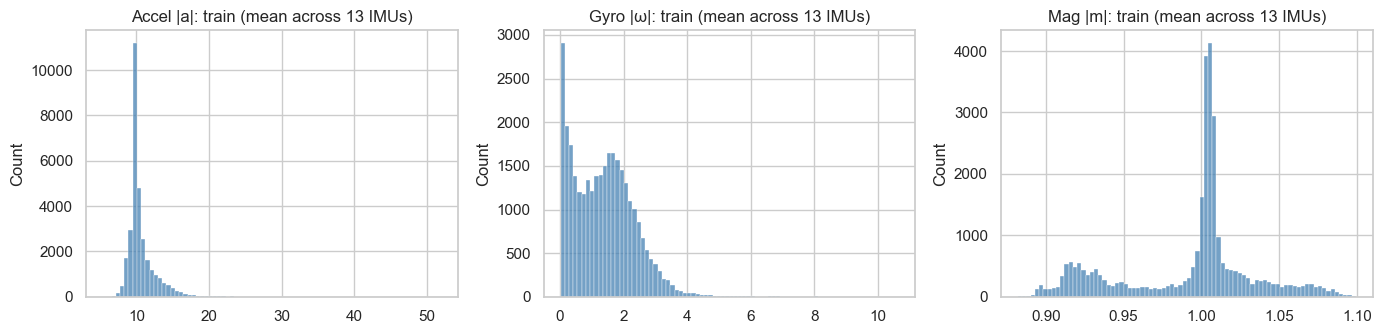

In [4]:
raw = splits['train']['raw_imu']
S = len(pp.SENSOR_ORDER)
raw_3d = raw.reshape(raw.shape[0], S, 13)

# По всем сенсорам: распределение accel-magnitude и gyro-magnitude
accel_mag = np.linalg.norm(raw_3d[:, :, 4:7], axis=2).mean(axis=1)
gyro_mag = np.linalg.norm(raw_3d[:, :, 7:10], axis=2).mean(axis=1)
mag_mag = np.linalg.norm(raw_3d[:, :, 10:13], axis=2).mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, sig, name in zip(axes, [accel_mag, gyro_mag, mag_mag], ['Accel |a|', 'Gyro |ω|', 'Mag |m|']):
    sns.histplot(sig, bins=80, ax=ax, color='steelblue')
    ax.set_title(f'{name}: train (mean across 13 IMUs)')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/imu_distributions.png', dpi=120); plt.show()

**Наблюдения.** Акселерометр распределён вокруг ~9.8 м/с² (вектор гравитации) с хвостом в сторону резких движений. Гироскоп — разреженное распределение с пиком возле нуля (статичные позы) и тяжёлый хвост (быстрые повороты). Магнитометр — почти равномерное распределение по сенсорам, что ожидаемо: модуль магнитного поля Земли постоянен.

## 4. Корреляции между сенсорами

Высокая корреляция между сенсорами одного сегмента тела (например, левая рука: L_UpArm и L_LowArm) ожидаема и означает, что соседние сенсоры частично дублируют информацию.

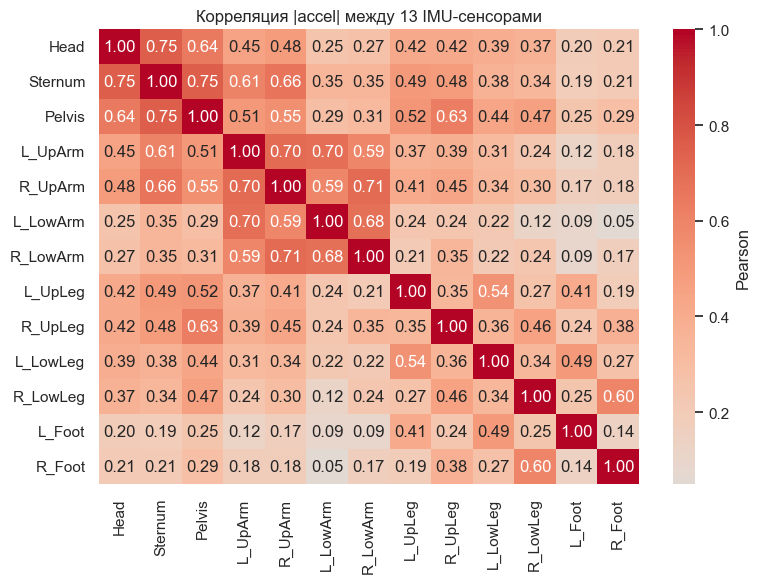

In [5]:
# Берём accel-magnitude по каждому из 13 сенсоров
accel_per = np.linalg.norm(raw_3d[:, :, 4:7], axis=2)
df_per = pd.DataFrame(accel_per, columns=pp.SENSOR_ORDER)
corr = df_per.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'Pearson'})
ax.set_title('Корреляция |accel| между 13 IMU-сенсорами')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/imu_corr.png', dpi=120); plt.show()

## 5. Распределение целевой переменной

Y = относительные позиции 14 суставов от Hips, плоский вектор размера 42.

In [6]:
Y_train = splits['train']['Y'].reshape(-1, 14, 3)
joint_means = Y_train.mean(axis=0)
joint_stds = Y_train.std(axis=0)
df_y = pd.DataFrame({
    'joint': pp.TARGET_JOINTS,
    'mean_x': joint_means[:, 0], 'mean_y': joint_means[:, 1], 'mean_z': joint_means[:, 2],
    'std_x': joint_stds[:, 0], 'std_y': joint_stds[:, 1], 'std_z': joint_stds[:, 2],
    'mean_dist_to_hips': np.linalg.norm(joint_means, axis=1),
})
df_y.round(2)

,joint,mean_x,mean_y,mean_z,std_x,std_y,std_z,mean_dist_to_hips
0,Spine,5.02,-31.350000,-6.91,25.379999,2.19,42.270000,32.500000
1,Spine1,5.02,-32.540001,-7.77,25.379999,2.19,42.270000,33.830002
2,Spine2,5.02,-32.849998,-7.81,25.379999,2.19,42.270000,34.139999
3,Spine3,5.02,-33.169998,-7.82,25.379999,2.19,42.270000,34.450001
4,Neck,5.02,-34.529999,-13.72,25.379999,2.19,42.270000,37.500000
5,Head,5.02,-34.040001,-9.11,25.379999,2.19,42.270000,35.590000
6,RightShoulder,6.16,-35.080002,-10.38,25.379999,2.19,42.270000,37.099998
7,RightArm,10.71,-33.169998,-4.19,25.379999,2.19,42.259998,35.110001
8,RightForeArm,16.34,-33.169998,-4.19,25.360001,2.19,42.259998,37.209999
9,RightHand,13.63,-33.169998,-4.19,25.360001,2.19,42.259998,36.099998


## 6. Визуализация скелета

Один кадр из train (acting1, кадр 500) — ground truth скелет в 3D.

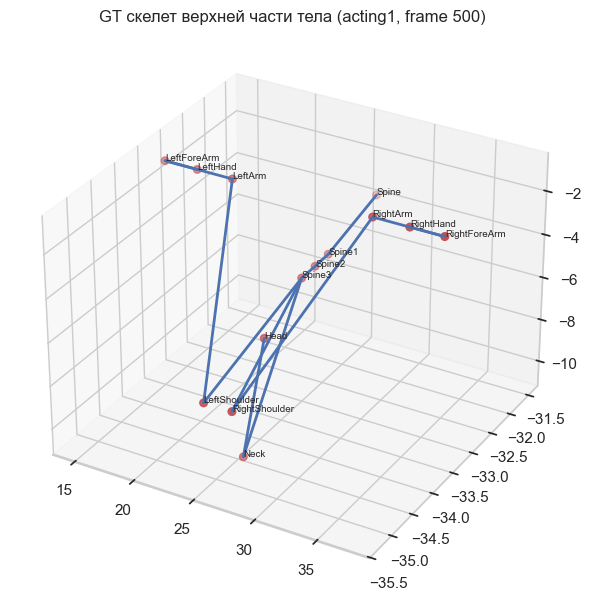

In [7]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
BONES = [
    ('Spine', 'Spine1'), ('Spine1', 'Spine2'), ('Spine2', 'Spine3'),
    ('Spine3', 'Neck'), ('Neck', 'Head'),
    ('Spine3', 'RightShoulder'), ('RightShoulder', 'RightArm'),
    ('RightArm', 'RightForeArm'), ('RightForeArm', 'RightHand'),
    ('Spine3', 'LeftShoulder'), ('LeftShoulder', 'LeftArm'),
    ('LeftArm', 'LeftForeArm'), ('LeftForeArm', 'LeftHand'),
]
frame = Y_train[500]
name_to_idx = {n: i for i, n in enumerate(pp.TARGET_JOINTS)}
fig = plt.figure(figsize=(6, 7))
ax = fig.add_subplot(111, projection='3d')
for j1, j2 in BONES:
    p1, p2 = frame[name_to_idx[j1]], frame[name_to_idx[j2]]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], 'b-', lw=2)
ax.scatter(frame[:, 0], frame[:, 1], frame[:, 2], c='r', s=30)
for n, p in zip(pp.TARGET_JOINTS, frame):
    ax.text(p[0], p[1], p[2], n, fontsize=7)
ax.set_title('GT скелет верхней части тела (acting1, frame 500)')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/skeleton_sample.png', dpi=120); plt.show()

## 7. Сравнение распределений X между train / val / test

Проверяем, не сильно ли отличаются распределения фичей в hold-out сплитах. Сильный сдвиг означал бы distribution shift — основной риск переобучения.

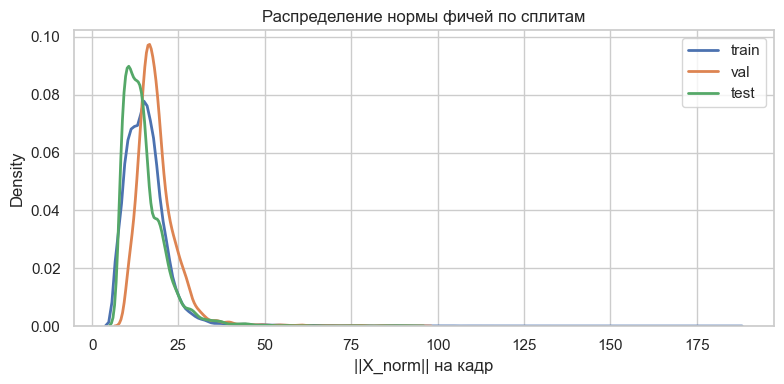

In [8]:
# Берём L2-норму признакового вектора кадра как сводку
fig, ax = plt.subplots(figsize=(8, 4))
for split, d in splits.items():
    norms = np.linalg.norm(d['X_norm'], axis=1)
    sns.kdeplot(norms, label=split, ax=ax, lw=2)
ax.set_xlabel('||X_norm|| на кадр')
ax.set_title('Распределение нормы фичей по сплитам')
ax.legend()
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/split_distributions.png', dpi=120); plt.show()

## 8. Feature engineering

Из исходных IMU-показаний (13 сенсоров × 13 каналов = 169) построено **305 фичей** на кадр:

Для каждого из 13 сенсоров (23 фичи):
- 4 — калиброванная ориентация в глобальной системе (R_ref⁻¹ · R_imu · R_bone), кватернион
- 3 — акселерометр в локальной системе IMU
- 3 — гироскоп
- 3 — магнитометр
- 4 — ∆ кватерниона между кадрами (производная)
- 3 — ∆ акселерометра
- 3 — ∆ гироскопа

Плюс 6 глобальных:
- 3 — позиция Hips
- 3 — её velocity

**Цель** velocity-фичей: дать модели информацию о *динамике* без необходимости использовать рекуррентные слои; для классических моделей (Linear/RF/GBM) это критично, иначе они не видят временной контекст.

## 9. Самостоятельный парсинг

Все парсеры (`.sensors`, калибровки `.txt`, `.bvh`) написаны вручную в `src/preprocessing.py` — готовых библиотек для этого формата TotalCapture нет. Парсер BVH использует тот факт, что в данном датасете каждый сустав имеет 6 каналов (Xposition Yposition Zposition + 3 угла Эйлера ZXY), причём первые 3 — глобальные координаты, что избавляет от необходимости явного forward kinematics.